In [4]:
import numpy as np
import matplotlib.pyplot as plt

Estimated coefficients: [ 1.89367149  3.08333733  5.0103216  10.01033678]


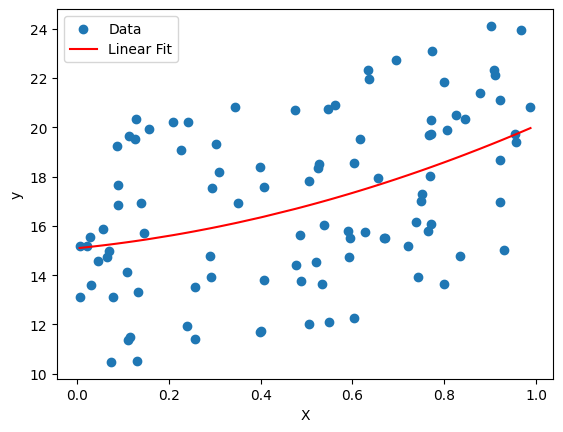

In [25]:
n = 100
x1 = np.random.uniform(0, 1, n)
X = np.column_stack((x1, x1**2, np.random.uniform(0, 2, n), np.ones(n)))
y = 2 * X[:, 0] + 3 * X[:,1] + 5 * X[:, 2] + 10 * X[:, 3] + np.random.normal(0, 0.1, n)
B = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated coefficients:", B)
y_pred = X @ B
# plot data
X_pred = np.column_stack((X[:, 0], X[:, 1], np.mean(X[:, 2]) * np.ones(n), np.ones(n)))
X_pred = X_pred[np.argsort(X_pred[:, 0])]
y_plot = X_pred @ B
plt.scatter(X[:, 0], y, label='Data')
plt.plot(X_pred[:, 0], y_plot, color='red', label='Linear Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
# beta error calculation
y_error = y - y_pred
mse = np.mean(y_error**2)
print("Mean Squared Error:", mse)
B_error = np.sqrt(mse * np.linalg.inv(X.T @ X).diagonal())
alpha = 0.05
ci_lower = B - 1.96 * B_error
ci_upper = B + 1.96 * B_error
p_values = 2 * (1 - np.abs(B / B_error))
print(f"Coefficients: {B}, Standard Errors: {B_error}, 95% CI: [{ci_lower}, {ci_upper}], p-values: {p_values}")

Mean Squared Error: 0.011249316930026197
Standard error of coefficients: [0.14131581 0.1440212  0.01807276 0.0343302 ]
Coefficients: [ 1.89367149  3.08333733  5.0103216  10.01033678], Standard Errors: [0.14131581 0.1440212  0.01807276 0.0343302 ], 95% CI: [[1.61669251 2.80105577 4.97489899 9.94304958], [ 2.17065047  3.36561888  5.0457442  10.07762397]], p-values: [ -24.80056174  -40.81782525 -552.46126222 -581.17960881]
